# 10. 텍스트 분석 실습 - 캐글 Mercari Price Suggection Challenge

- trainjd： 데이터 id
- name： 제품명
- item_conditionjd： 판매자가 제공하는 제품 상태
- category_name： 카테고리 명
- brand_name： 브랜드 이름
- price： 제품 가격. 예측을 위한 타깃 속성
- shipping： 배송비 무료 여부. 1 이면 무료(판매자가 지불), 0이면 유료(구매자 지불)
- item_description： 제품에 대한 설명

###**데이터 전처리**

In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df = pd.read_csv('/content/drive/MyDrive/data/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [2]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


brand_name 칼럼의 경우 매우 많은 Null값을 가지고 있다.

brand_name은 가격에 영향을 많이 미치는 중요 요인으로 판단되지만, 많은 데이터가 Null로 되어 있다.

Null 데이터는 이후에 적절한 문자열로 치환

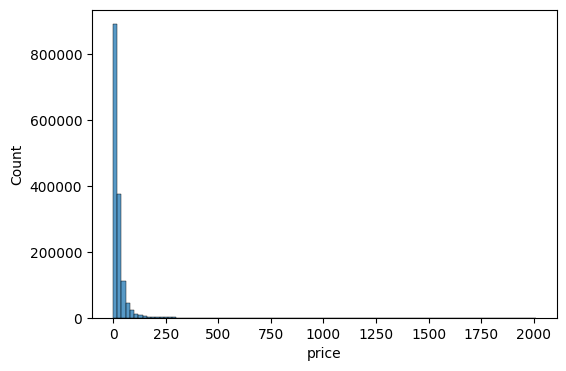

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df= mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

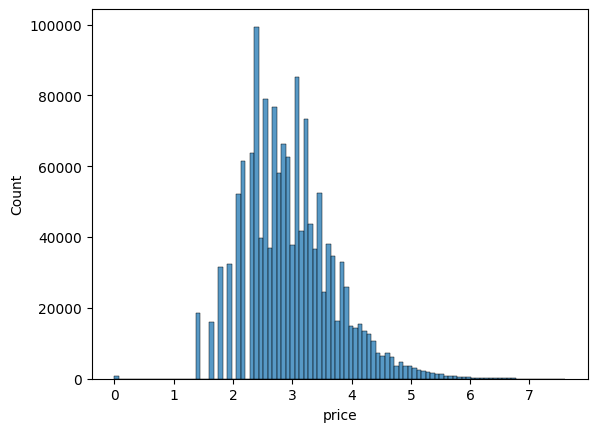

In [4]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=100)
plt.show()

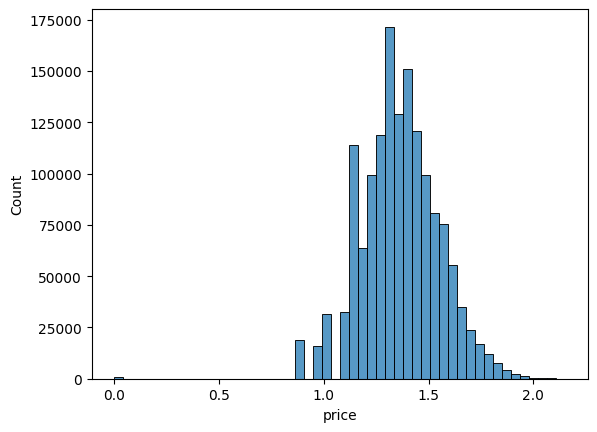

In [5]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [6]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [7]:
print('Shippint 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition 값 유형:\n', mercari_df['item_condition_id'].value_counts())

Shippint 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


Shipping 칼럼은 배송비 유무이며, 값이 비교적 균일하다.
Item_condition_id는 판매자가 제공하는 제품의 상태로서 각 값이 의미하는 바는 캐글에 기재돼 있지 않아서 알 수는 없으나 1,2,3 값이 주를 이루고 있다.

In [8]:
boolean_cond = (mercari_df['item_description'] == 'No description yet')
mercari_df[boolean_cond]['item_description'].count()

np.int64(82489)

item_description이 'No descriptio yet'으로 되어있는 로우의 개수는 위와 같음

'No description yet'의 경우도 Null과 마찬가지로 의미 있는 속성값으로는 사용될 수 없으므로 적절한 값으로 변경해야 한다.

In [9]:
def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return ['Other_Null', 'Other_Null', 'Other_Null']

#위의 split_cat()을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

#대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형:\n', mercari_df['cat_dae'].value_counts())
print('\n중분류 유형:\n', mercari_df['cat_jung'].nunique())
print('\n소분류 유형:\n', mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64

중분류 유형:
 114

소분류 유형:
 871


대분류의 경우 Women, Beauty, Kids 등의 분류가 매우 많다.

중분류 유형은 114개, 소분류는 817개로 구성되어 있다.

- brand_name, category_name, item_description 칼럼의 Null값은 일괄적으로 'Other Null'로 동일하게 변경
- brand_name은 price값 결정에 영향을 많이 줄 것으로 판단되지만, Null값이 매우 많음
- Null값을 다른 값으로 변경하는 것은 적절하지 않을 것으로 판단되므로 일괄적으로 'Other_Null'로 변경한다.

In [10]:
mercari_df['brand_name']= mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name']= mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

#각 칼럼별로 Null값 건수 확인. 모두 0이 나와야 함
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


###**피처 인코딩 피처 벡터화**

Mercari Price Suggestion에 이용되는 데이터 세트는 문자열 칼럼이 많다. 이 문자열 칼럼 중 레이블 또는 원-핫 인코딩을 수행하거나 피처 벡터화로 변환할 칼럼을 선별

예측 모델은 price값을 예측해야 하므로 회귀 모델을 기반으로 한다.

선형 회귀 모델과 회귀 트리 모델을 모두 적용할 예정이며, 특히 선형 회귀의 경우 원-핫 인코딩 적용이 훨씬 선호되므로 인코딩할 피처는 모두 원-핫 인코딩을 적용한다.

피처 벡터화의 경우, 비교적 짧은 텍스트의 경우는 Count기반의 벡터화를, 긴 텍스트는 TF-IDF기반의 벡터화를 적용한다.

In [11]:
print('brand name의 유형 건수:', mercari_df['brand_name'].nunique())
print('brand name sample 5건: \n', mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수: 4810
brand name sample 5건: 
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


브랜드 네임의 경우 별도의 피처 벡터화 형태로 만들 필요 없이 인코딩 변환을 적용하면 된다.

In [12]:
print('name의 종류 개수:', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name의 종류 개수: 1225273
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


Name 속성은 유형이 매우 많고, 적은 단어 위주의 텍스트 형태로 되어 있으므로 Count 기반으로 피처 벡터화 변환을 적용한다.

In [13]:
pd.set_option('max_colwidth', 200)

#item_description의 평균 문자열 크기
print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 145.71139703278507


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


평균 문자열이 145자로 비교적 크므로 해당 칼럼은 TF-IDF로 변환한다.

In [14]:
#name 속성에 대한 피처 벡터화 변환
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

#item_description에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (1482535, 105757)
item_description vectorization shape: (1482535, 50000)


CountVectorizer, TFidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태이다. 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 한다.

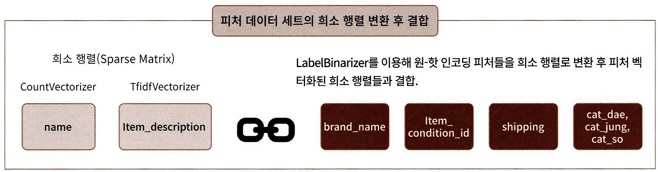

In [15]:
from sklearn.preprocessing import LabelBinarizer

#brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])


#cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [16]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae.shape{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae.shape(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape:(1482535, 871)


인코딩 변환된 데이터 세트가 CSR형태로 변환된 csr_matrix 타입이다.

brand_name칼럼 경우 값의 유형이 4810개이므로 이를 원-핫 인코딩으로 변화한 X_brand_shape의 경우 4810개의 인코딩 칼럼을 가지게 되었다.

X_cat_so도 마찬가지로 871개의 인코딩 칼럼을 가진다.


**피처 벡터화 변환한 데이터 세트와 희소 인코딩 변환된 데이터 세트를 hstack()을 이용하여 모두 결합**



In [16]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_item_cond_id, X_brand, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

#hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print('희소 feature 데이터 shape:{0}', X_features_sparse.shape)

#데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제
del X_features_sparse
gc.collect()

###**릿지 회귀 모델 구축 및 평가**

$$\epsilon = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\log(p_i + 1) - \log(a_i + 1))^2}$$

위와 같이 모델을 평가하는 평가 로직을 함수화한다.

In [18]:
def rmsle(y, y_pred):
  #underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle계산
  return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):

  #원본 데이터는 log1p로 변환되었으므로 exmpm1로 원복 필요
  preds_exmpm = np.expm1(preds)
  y_test_exmpm = np.expm1(y_test)

  #rmsle로 RMSLE값 추출
  rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
  return rmsle_result

학습용 데이터를 생성하고 모델을 학습/예측하는 로직을 별도의 함수로 만든다.

- model_train_predict()함수는 model인자로 사이킷런의 회귀 estimator객체를, matrix 인자로 최종 데이터 세트로 결합할 희소 행렬 리스트를 가진다.

In [19]:
import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
  #scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
  X = hstack(matrix_list).tocsr()

  X_train, X_test,y_train, y_test = train_test_split(X, mercari_df['price'], test_size=0.2, random_state=156)

  #모델 학습 및 예측
  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  del X, X_train, X_test, y_train
  gc.collect()

  return preds, y_test

개별 함수를 만들었으면 이제 이를 이용하여 먼저 Ridge를 활용한 Mercari Price의 회귀 예측을 수행

- Mercari 상품 가격 예측에 item_description과 같은 텍스트 형태의 속성이 얼마나 영향을 미치는지 알아보자.

In [20]:
linear_model = Ridge(solver='lsqr', fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list = sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle값:', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list = sparse_matrix_list)
print('Item Description을 포함한 rmsle값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle값: 0.49844618751690567
Item Description을 포함한 rmsle값: 0.4681044600127017


###**LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가**

In [ ]:
#from lighgbm import LGBMRegressor

#sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
#                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

#lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
#lgbm_preds, y_test = model_train_predict(model = lgbm_model, matrix_list=sparse_matrix_list)
#print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

In [ ]:
#preds = lgbm_preds*0.45+linear_preds*0.55
#print('LightGBM과 Ridge를 ensemble한 최종 rmsle값:', evaluate_org_price(y_test, preds))

###**정리**

머신러닝 기반의 텍스트 분석 프로세스
1. 텍스트 사전 정제 작업 등의 텍스트 정규화 작업을 수행
2. 이들 단어들을 피처 벡터화로 변환
3. 생성된 피처 벡터 데이터 세트에 머신러닝 모델을 학습하고 예측, 평가


텍스트 정규화 작업은 텍스트 클렌징 및 대소문자 변경, 단어 토큰화, 의미 없는 단어 필터링, 어근 추출 등 피처 벡터화를 진행하기 이전에 수행하는 다양한 사전 작업을 의미